# NOTEBOOK 01 — DATA EXPLORATION & EDA   

## Library Imports and Environment Configuration

This section initialises the analytical environment by importing the core Python libraries required for data manipulation, numerical computation, and visualisation. The notebook relies primarily on the *pandas* and *NumPy* ecosystems for structured data processing, while *matplotlib* and *seaborn* are used for statistical visualisation.

To ensure reproducibility and modular project organisation, the parent project directory is added to the system path. This enables access to shared configuration variables such as dataset locations and output directories defined in the `config` module.

Visualisation parameters are also standardised at this stage. Consistent styling improves interpretability and ensures that generated plots maintain a uniform appearance across the entire analysis pipeline. Non-critical warnings are suppressed to avoid unnecessary console noise during execution.

Finally, the configured plots directory is displayed to confirm that output paths have been correctly initialised.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Data Science Libraries
import pandas as pd
import numpy as np

# Visualisation Libraries
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Suppress non-critical warning
import warnings
warnings.filterwarnings('ignore')

# Label Wrapping 
import textwrap

# Project Configuration Imports
from config import HOSP_DIR, ICU_DIR, PLOTS_DIR

# Matplotlib styling
plt.rcParams.update({
    'figure.dpi' : 120,
    'axes.spines.top' : False,
    'axes.spines.right' : False,
    'font.size' : 11,
})

# Custom color palette for all seaborn plots
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#2A9D8F', '#8338EC']
sns.set_palette(PALETTE)

print(f'Plots directory : {PLOTS_DIR}')

Plots directory : D:\Lancaster University Coursework\Term 2\SCC 453 - Natural Language Processing and Language Models\Coursework Code\using mimic data\medical_nlp_deterioration\results\plots


## Data Loading and Initial Pre-processing

This section loads the core clinical datasets required for the exploratory analysis. The data sources originate from the hospital and intensive care modules, including patient demographics, admissions, diagnoses, prescriptions, laboratory events, and ICU stay information. Reference dictionaries for ICD diagnoses and laboratory items are also imported to enable semantic interpretation of coded variables in later stages of the analysis.

Temporal variables are explicitly converted into datetime format to ensure correct handling of time-based computations. This is particularly important for calculating clinically meaningful measures such as length of hospital stay, which is derived from the difference between discharge and admission timestamps.

A preliminary schema summary is then generated to provide a quick overview of dataset sizes and dimensionality. This step serves as an early validation checkpoint, confirming that files have been loaded correctly and allowing the analyst to assess the scale of each table before proceeding with further integration or feature engineering.

In [2]:
# Clinical Dataset Loading
patients = pd.read_csv(f'{HOSP_DIR}/patients.csv.gz')
admissions = pd.read_csv(f'{HOSP_DIR}/admissions.csv.gz')
diagnoses = pd.read_csv(f'{HOSP_DIR}/diagnoses_icd.csv.gz')
prescriptions = pd.read_csv(f'{HOSP_DIR}/prescriptions.csv.gz')
labevents = pd.read_csv(f'{HOSP_DIR}/labevents.csv.gz')
icustays = pd.read_csv(f'{ICU_DIR}/icustays.csv.gz')

# Reference Tables
d_icd_diag = pd.read_csv(f'{HOSP_DIR}/d_icd_diagnoses.csv.gz')
d_labitems = pd.read_csv(f'{HOSP_DIR}/d_labitems.csv.gz')

# Convert timestamps to datetime format
for col in ['admittime', 'dischtime', 'deathtime']:
    if col in admissions.columns:
        admissions[col] = pd.to_datetime(admissions[col], errors='coerce')

# ICU Stay Timestamps
icustays['intime']  = pd.to_datetime(icustays['intime'],  errors='coerce')
icustays['outtime'] = pd.to_datetime(icustays['outtime'], errors='coerce')

# Compute Length of Stay (LOS) in Days
admissions['los_days'] = (
    (admissions['dischtime'] - admissions['admittime'])
    .dt.total_seconds() / 86400
)

# Quick schema summary
print(f'{"Table":<18} {"Rows":>8}  {"Cols":>6}')
print('─' * 36)
for name, df in [
    ('patients', patients), 
    ('admissions', admissions),
    ('diagnoses', diagnoses), 
    ('prescriptions', prescriptions),
    ('labevents', labevents), 
    ('icustays', icustays)
]:
    print(f'{name:<18} {df.shape[0]:>8,}  {df.shape[1]:>6}')

Table                  Rows    Cols
────────────────────────────────────
patients                100       6
admissions              275      17
diagnoses             4,506       5
prescriptions        18,087      21
labevents           107,727      16
icustays                140       8


## Patient Demographics Exploration

This section presents an exploratory analysis of the patient population characteristics. Understanding demographic distributions is an essential preliminary step in clinical data analysis, as it provides insight into cohort composition and potential sources of bias that may influence downstream modelling tasks.

Three key demographic attributes are examined:

1. **Age Distribution** — The histogram illustrates the spread of patient ages within the cohort, with the mean age indicated to provide a central tendency reference. Age is a critical determinant in clinical outcome prediction and healthcare utilisation patterns.

2. **Gender Distribution** — A categorical comparison of gender frequencies is presented to assess cohort balance. Percentage annotations are included to facilitate proportional interpretation beyond absolute counts.

3. **Cohort Year Group** — When available, the temporal grouping of patient records is visualised to understand the longitudinal structure of the dataset and potential temporal trends in data collection.

The combined visualisation provides a concise overview of demographic characteristics while maintaining consistency in styling and layout. Summary statistics are printed to complement the graphical interpretation and support quantitative reporting.

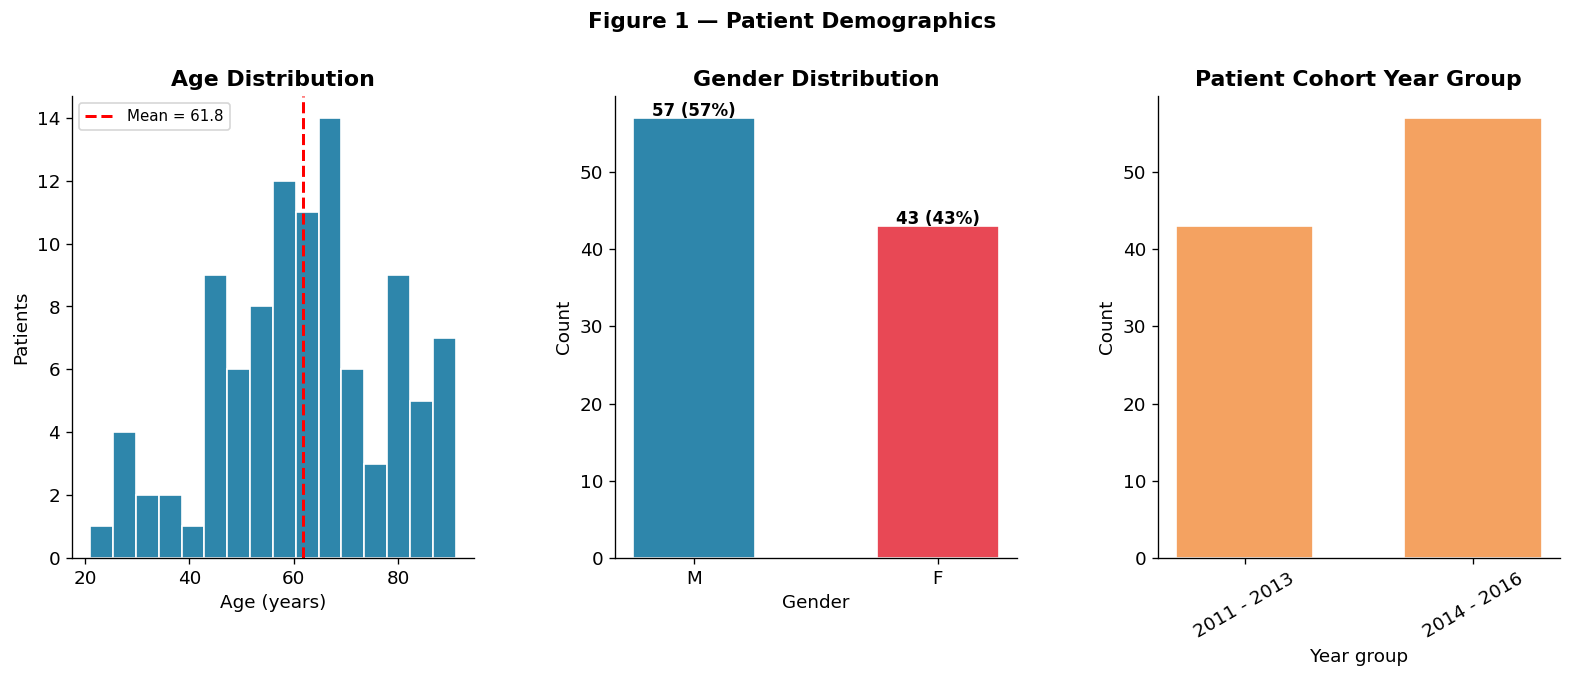

Total patients : 100
Age mean ± std : 61.8 ± 16.2
Female / Male : 43 / 57


In [3]:
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Age distribution
ax1 = fig.add_subplot(gs[0])

ax1.hist(
    patients['anchor_age'], 
    bins=16, 
    color=PALETTE[0], 
    edgecolor='white'
)

# Mean Reference Line
ax1.axvline(
    patients['anchor_age'].mean(),
    color='red',
    linestyle='--',
    lw=1.8,
    label=f'Mean = {patients["anchor_age"].mean():.1f}'
)

ax1.set_title('Age Distribution', fontweight='bold')
ax1.set_xlabel('Age (years)'); ax1.set_ylabel('Patients')
ax1.legend(fontsize=9)

# Gender distribution
ax2 = fig.add_subplot(gs[1])
gc   = patients['gender'].value_counts()

bars = ax2.bar(
    gc.index,
    gc.values,
    color=[PALETTE[0], PALETTE[1]],
    edgecolor='white',
    width=0.5
)

# Annotate counts and percentages
for bar, val in zip(bars, gc.values):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val} ({val/len(patients)*100:.0f}%)',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

ax2.set_title('Gender Distribution', fontweight='bold')
ax2.set_xlabel('Gender')
ax2.set_ylabel('Count')

# Cohort year group (temporal grouping of patient records)
ax3 = fig.add_subplot(gs[2])


if 'anchor_year_group' in patients.columns:
    yr = patients['anchor_year_group'].value_counts().sort_index()

    ax3.bar(
        yr.index,
        yr.values,
        color=PALETTE[2],
        edgecolor='white',
        width=0.6
    )

    ax3.tick_params(axis='x', rotation=30)

ax3.set_title('Patient Cohort Year Group', fontweight='bold')
ax3.set_xlabel('Year group')
ax3.set_ylabel('Count')

plt.suptitle('Figure 1 — Patient Demographics', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/eda_01_patient_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print(f'Total patients : {len(patients)}')

print(
    f'Age mean ± std : {patients["anchor_age"].mean():.1f} ± '
    f'{patients["anchor_age"].std():.1f}'
)

print(
    f'Female / Male : {gc.get("F",0)} / {gc.get("M",0)}'
)

## Admissions Characteristics and Healthcare Utilisation Patterns

This section explores hospital admission patterns to better understand patient healthcare utilisation behaviour within the dataset. Admission frequency and administrative attributes are important contextual factors that may influence clinical outcomes and predictive modelling performance.

Three complementary perspectives are presented:

1. **Admissions per Patient** — The distribution of admission counts per individual provides insight into repeat hospitalisation patterns and potential chronic disease burden within the cohort. Patients with multiple admissions may represent higher-risk populations or those requiring ongoing care.

2. **Admission Types** — The most frequent admission categories are visualised to examine the clinical context under which patients enter the healthcare system (e.g., emergency, elective, or urgent admissions). Differences in admission pathways can have significant implications for patient prognosis and resource allocation.

3. **Discharge Locations** — Discharge destination serves as a proxy indicator of post-hospital care needs and patient recovery status. Analysing discharge patterns can reveal the proportion of patients returning home versus those requiring rehabilitation or extended care services.

Summary statistics are included to quantify admission frequency, including the proportion of patients with multiple hospital encounters and the maximum observed number of admissions for a single patient. These descriptive insights provide a foundation for subsequent feature engineering and outcome prediction analyses.

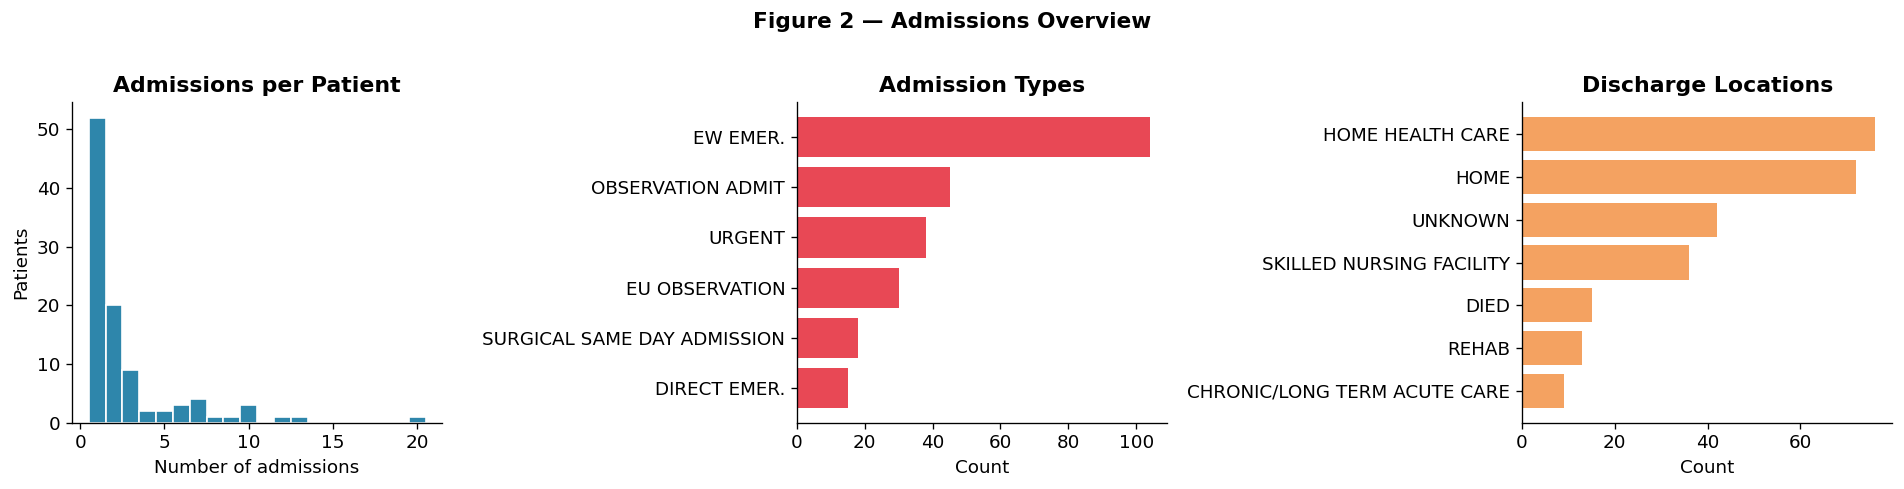

Total admissions : 275
Patients with >1 admission : 48 (48%)
Max admissions (one patient) : 20


In [4]:
# Number of admissions per patient
adm_per_pt = admissions.groupby('subject_id').size()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Admissions per Patient Distribution
axes[0].hist(
      adm_per_pt.values,
      bins=range(1, adm_per_pt.max() + 2),
      color=PALETTE[0],
      edgecolor='white',
      align='left'
)

axes[0].set_title('Admissions per Patient', fontweight='bold')
axes[0].set_xlabel('Number of admissions')
axes[0].set_ylabel('Patients')

# Admission Types
adm_type = admissions['admission_type'].value_counts().head(6)

axes[1].barh(
      adm_type.index[::-1],
      adm_type.values[::-1],
      color=PALETTE[1]
)

axes[1].set_title('Admission Types', fontweight='bold')
axes[1].set_xlabel('Count')

# Discharge Locations
disch = (
      admissions['discharge_location']
      .fillna('UNKNOWN')
      .value_counts()
      .head(7)
)

axes[2].barh(
      disch.index[::-1],
      disch.values[::-1],
      color=PALETTE[2]
)

axes[2].set_title('Discharge Locations', fontweight='bold')
axes[2].set_xlabel('Count')

# Plot
plt.suptitle(
      'Figure 2 — Admissions Overview',
      fontsize=13,
      fontweight='bold',
      y=1.01
)

plt.tight_layout()

plt.savefig(
      f'{PLOTS_DIR}/eda_02_admissions_overview.png',
      dpi=150,
      bbox_inches='tight'
)

plt.show()

print(f'Total admissions : {len(admissions):,}')

print(
      f'Patients with >1 admission : {(adm_per_pt > 1).sum()} '
      f'({(adm_per_pt > 1).mean()*100:.0f}%)'
)

print(
      f'Max admissions (one patient) : {adm_per_pt.max()}'
)


## Length of Stay (LOS) Analysis

Length of hospital stay (LOS) is an important indicator of healthcare utilisation, disease severity, and resource consumption within clinical settings. Analysing LOS distributions provides insight into patient flow dynamics and helps identify cases associated with prolonged hospitalisation.

In this section, LOS values are first cleaned by removing missing observations and capping extreme outliers to improve visual interpretability. Two complementary analyses are then presented:

1. **LOS Distribution** — A histogram illustrates the overall spread of hospital stay durations, with both mean and median values indicated to highlight potential skewness in the distribution.

2. **LOS by Admission Type** — A comparative boxplot evaluates differences in LOS across admission categories, allowing identification of admission pathways associated with longer hospitalisation periods.

Summary statistics are provided to quantify central tendency and the proportion of extended stays (greater than 14 days), which may be clinically relevant for identifying high-risk patient groups.

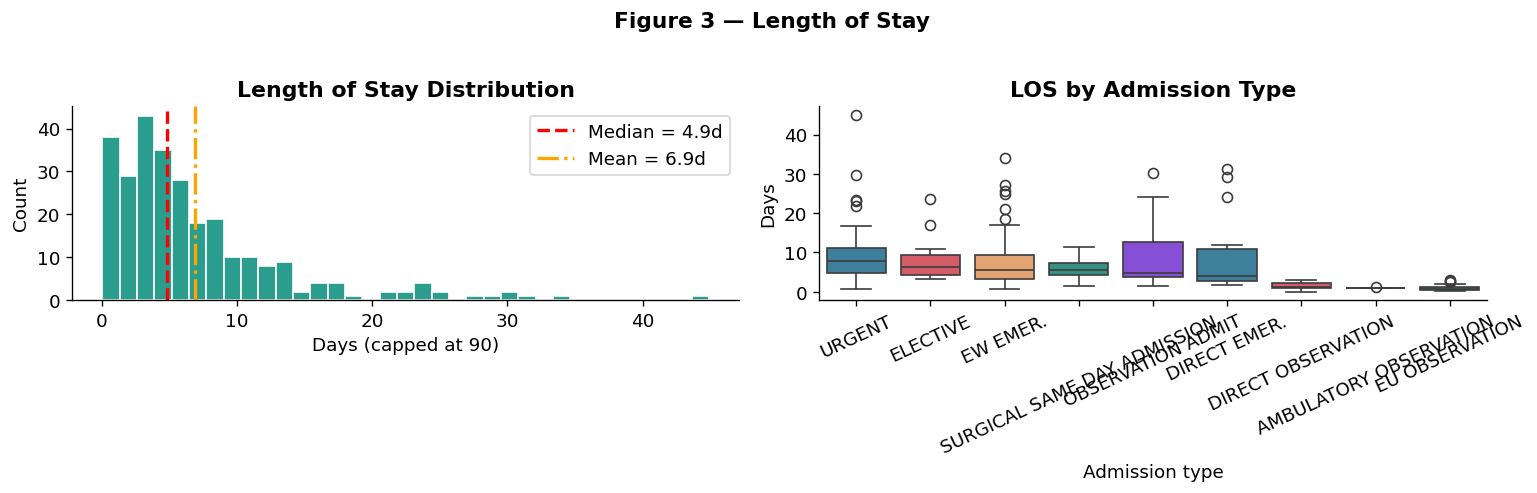

LOS median : 4.9 days
LOS mean : 6.9 days
LOS > 14d : 31 (11.3%)


In [5]:
# Clean Length of Stay (LOS)
los_clean = admissions['los_days'].dropna().clip(0, 90)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# LOS Distribution
axes[0].hist(
    los_clean,
    bins=35,
    color=PALETTE[3],
    edgecolor='white'
)

# Median LOS
axes[0].axvline(
    los_clean.median(),
    color='red',
    linestyle='--',
    lw=2,
    label=f'Median = {los_clean.median():.1f}d'
)

# Mean LOS
axes[0].axvline(
    los_clean.mean(),
    color='orange',
    linestyle='-.',
    lw=2,
    label=f'Mean = {los_clean.mean():.1f}d'
)
        
axes[0].set_title('Length of Stay Distribution', fontweight='bold')
axes[0].set_xlabel('Days (capped at 90)')
axes[0].set_ylabel('Count')
axes[0].legend()

# LOS by Admission Type
los_type = admissions[['admission_type', 'los_days']].dropna()

# Remove extreme LOS valyes 
los_type  = los_type[los_type['los_days'] < 60]

# Order categories by median LOS
order = (
    los_type.groupby('admission_type')['los_days']
    .median()
    .sort_values(ascending=False)
    .index
)

# Boxplot visualisation
sns.boxplot(
    data=los_type,
    x='admission_type',
    y='los_days',
    order=order,
    ax=axes[1],
    palette=PALETTE
)

axes[1].set_title('LOS by Admission Type', fontweight='bold')
axes[1].set_xlabel('Admission type')
axes[1].set_ylabel('Days')
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle(
    'Figure 3 — Length of Stay',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{PLOTS_DIR}/eda_03_los_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Summary Statistics
print(f'LOS median : {los_clean.median():.1f} days')
print(f'LOS mean : {los_clean.mean():.1f} days')

print(
    f'LOS > 14d : {(los_clean > 14).sum()} '
    f'({(los_clean > 14).mean()*100:.1f}%)'
)

## Diagnosis Distribution and Clinical Category Analysis

Diagnostic information provides critical insight into the clinical conditions represented within the patient cohort. Understanding the frequency and distribution of diagnoses helps characterise disease burden, identify dominant clinical patterns, and support downstream feature engineering for predictive modelling.

In this section, diagnosis codes are enriched by merging with descriptive metadata to obtain human-readable titles. Diagnoses are further grouped into broader ICD chapters to enable higher-level clinical interpretation beyond individual codes.

Two complementary analyses are presented:

1. **Most Frequent Diagnoses** — The top occurring diagnosis descriptions are visualised to highlight dominant clinical conditions within the dataset.

2. **Diagnoses by ICD Chapter** — Aggregating diagnoses into major ICD categories provides a broader view of disease domains, facilitating identification of prevalent physiological systems affected in the cohort.

Summary statistics quantify dataset scale, including the total number of diagnosis records, the diversity of ICD codes, and the average number of diagnoses per hospital admission.

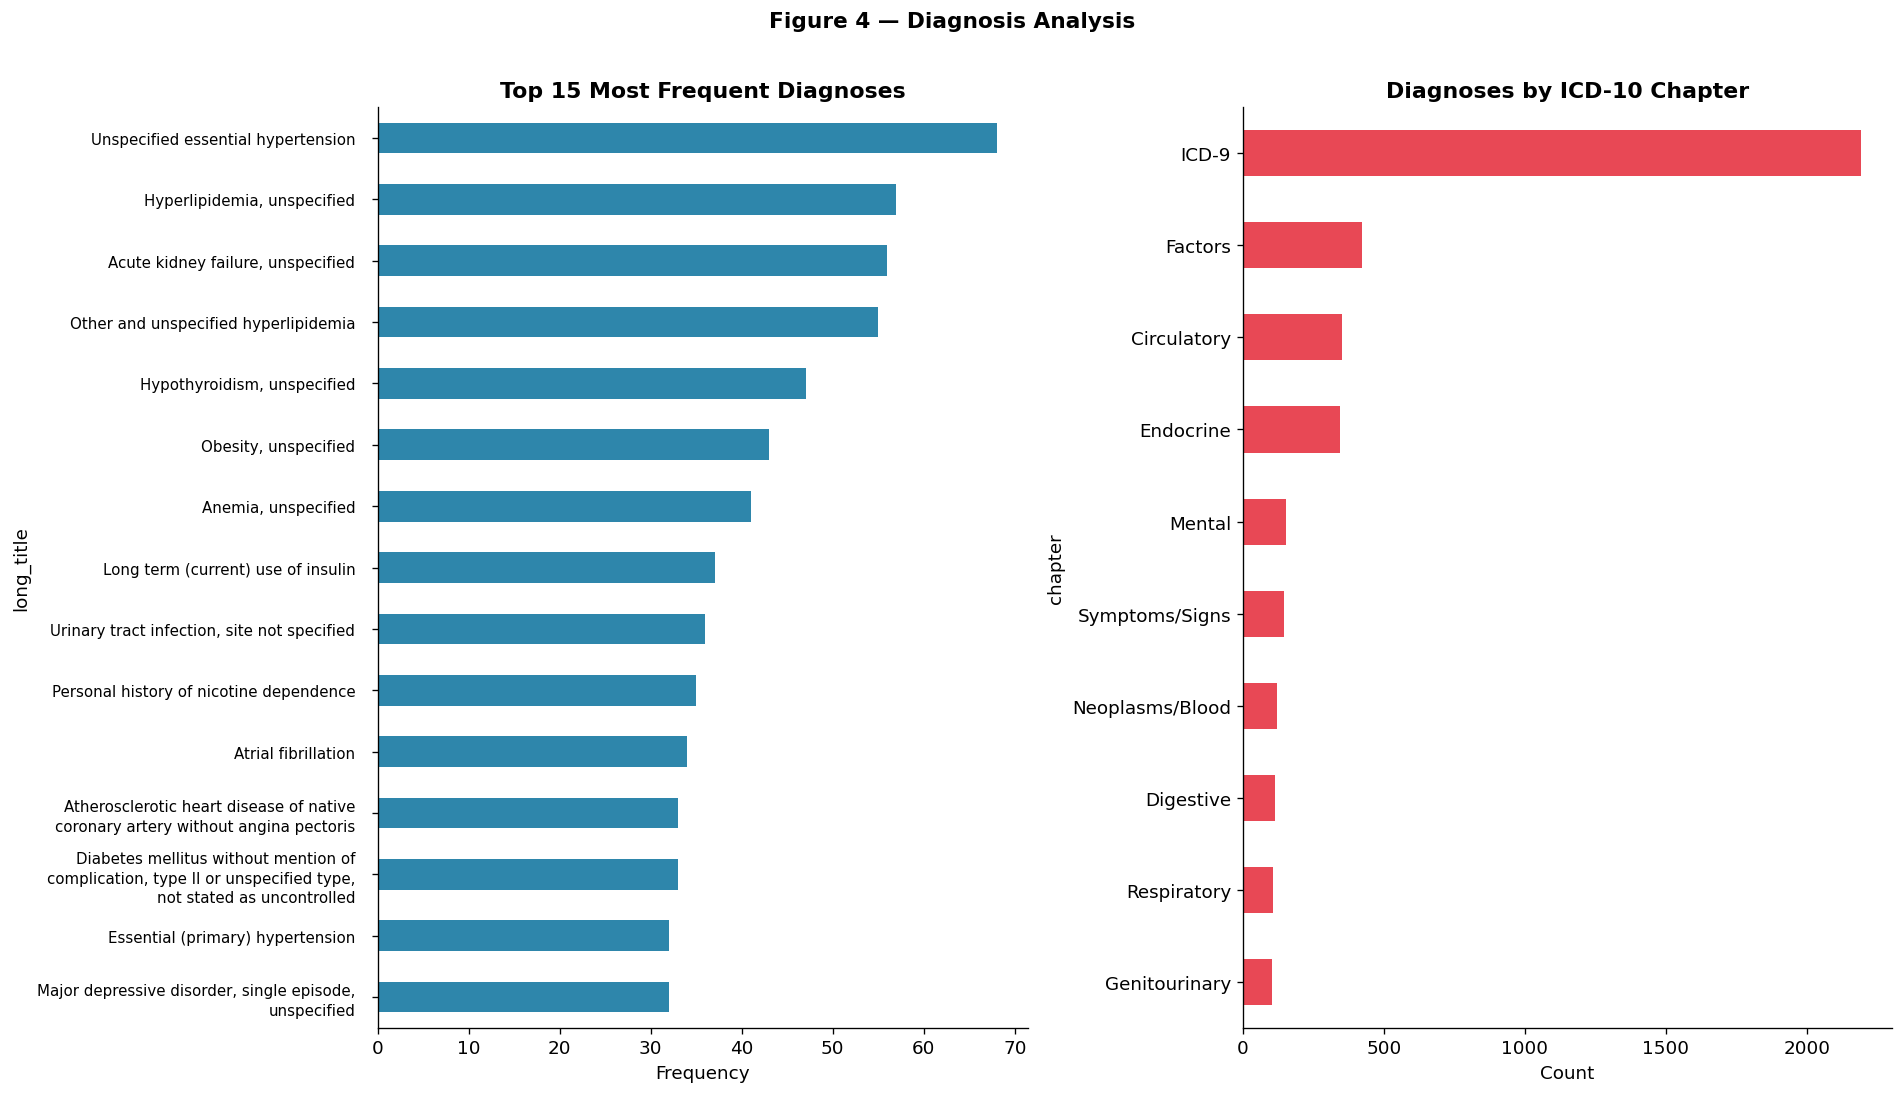

Total diagnosis records : 4,506
Unique ICD codes : 1472
Avg diagnoses/admission : 16.4


In [16]:
# Function to map ICD codes to broader ICD chapters
def icd_chapter(code, version):
    code = str(code).strip().upper()
    if version == 10:
        chapters = {
            'A': 'Infectious', 'B': 'Infectious', 'C': 'Neoplasms',
            'D': 'Neoplasms/Blood', 'E': 'Endocrine', 'F': 'Mental',
            'G': 'Nervous', 'H': 'Eye/Ear', 'I': 'Circulatory',
            'J': 'Respiratory', 'K': 'Digestive', 'L': 'Skin',
            'M': 'Musculoskeletal', 'N': 'Genitourinary',
            'R': 'Symptoms/Signs', 'S': 'Injury', 'T': 'Injury',
            'Z': 'Factors'
        }
        return chapters.get(code[0] if code else 'X', 'Other')
    return 'ICD-9'

# Merge Diagnosis Records with Metadata Descriptions
diagnoses_named = diagnoses.merge(
    d_icd_diag[['icd_code', 'icd_version', 'long_title']],
    on=['icd_code', 'icd_version'],
    how='left'
)

# Replace missing descriptions with ICD code itself
diagnoses_named['long_title'] = (
    diagnoses_named['long_title'].fillna(diagnoses_named['icd_code'])
)

# Assign ICD chapter categories
diagnoses_named['chapter'] = diagnoses_named.apply(
    lambda r: icd_chapter(r['icd_code'], r['icd_version']), 
    axis=1
)

# Compute top diagnoses and chapter frequencies
top15 = diagnoses_named['long_title'].value_counts().head(15)
chapter_counts = diagnoses_named['chapter'].value_counts()

# Visualisations
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# -------- Top diagnoses with wrapped labels --------
wrapped_labels = [
    textwrap.fill(lbl, width=45)   # adjust width as needed
    for lbl in top15[::-1].index
]

top15[::-1].plot(
    kind='barh',
    ax=axes[0],
    color=PALETTE[0]
)

axes[0].set_yticklabels(
    wrapped_labels,
    fontsize=9,
    linespacing=1.4   # space between lines
)

axes[0].tick_params(axis='y', pad=10)  # padding between label and axis
axes[0].set_title('Top 15 Most Frequent Diagnoses', fontweight='bold')
axes[0].set_xlabel('Frequency')

# Increase left margin so labels fit
plt.subplots_adjust(left=0.42)


# Diagnoses by ICD chapter
chapter_counts.head(10).sort_values().plot(
    kind='barh',
    ax=axes[1],
    color=PALETTE[1]
)

axes[1].set_title('Diagnoses by ICD-10 Chapter', fontweight='bold')
axes[1].set_xlabel('Count')

plt.suptitle(
    'Figure 4 — Diagnosis Analysis',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()

plt.savefig(
    f'{PLOTS_DIR}/eda_04_top_diagnoses.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Summary Statistics
print(f'Total diagnosis records : {len(diagnoses):,}')

print(
    f'Unique ICD codes : {diagnoses["icd_code"].nunique()}'
)

print(
    f'Avg diagnoses/admission : '
    f'{diagnoses.groupby("hadm_id").size().mean():.1f}'
)

## Laboratory Measurements and Data Coverage

Laboratory test data represents a critical component of clinical decision-making and is often highly informative for predictive modelling tasks. Analysing laboratory measurement patterns provides insight into both the clinical monitoring intensity and the availability of structured physiological information within the dataset.

This section examines laboratory data from two perspectives:

1. **Most Frequent Laboratory Tests** — Identifying commonly measured laboratory parameters helps determine which biomarkers are most consistently available across patients and may therefore be suitable for feature engineering.

2. **Laboratory Tests per Admission** — The distribution of laboratory events per hospital encounter reflects the level of clinical monitoring intensity and patient complexity. Admissions with a high number of laboratory tests may correspond to more severe conditions or longer hospital stays.

Summary statistics quantify the scale and diversity of laboratory data, including the total number of recorded measurements, the number of unique laboratory test types, and the average number of laboratory events per admission.

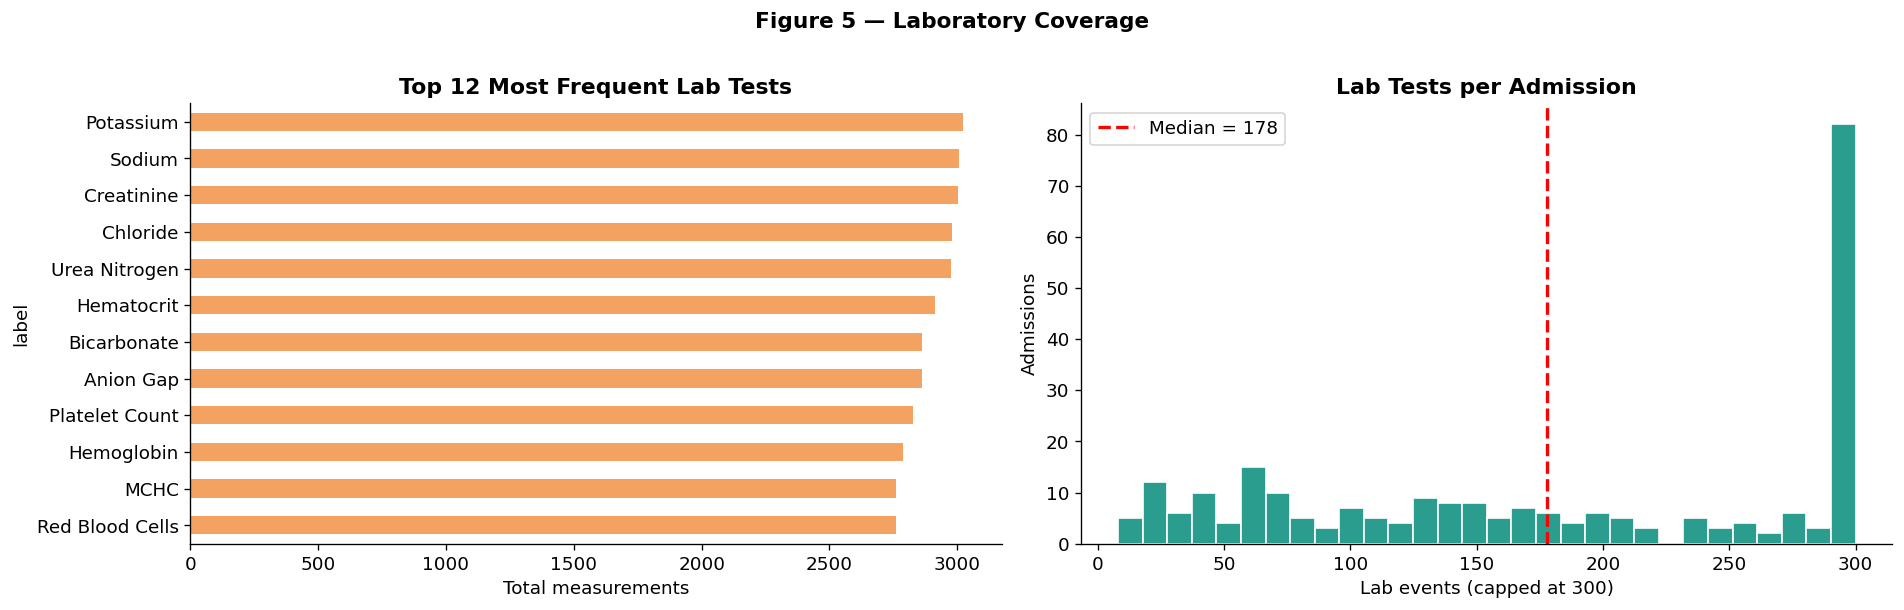

Total lab events : 107,727
Unique lab types : 498
Avg lab events/admission : 315


In [7]:
# Compute frequency of laboratory tests by itemid
lab_counts = (
    labevents.groupby('itemid').size()
    .reset_index(name='count')
    .merge(
        d_labitems[['itemid', 'label']],
        on='itemid',
        how='left'
    )
    .sort_values('count', ascending=False)
)

# Number of lab events per admission
labs_per_adm = labevents.groupby('hadm_id').size()

# Visualisations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top Laboratory Tests
lab_counts.set_index('label')['count'].head(12).sort_values().plot(
    kind='barh',
    ax=axes[0],
    color=PALETTE[2]
)

axes[0].set_title('Top 12 Most Frequent Lab Tests', fontweight='bold')
axes[0].set_xlabel('Total measurements')

# Lab tests per admission distribution
axes[1].hist(
    labs_per_adm.clip(0, 300),
    bins=30,
    color=PALETTE[3],
    edgecolor='white'
)

# Median reference line
axes[1].axvline(
    labs_per_adm.median(),
    color='red',
    linestyle='--',
    lw=2,
    label=f'Median = {labs_per_adm.median():.0f}'
)

axes[1].set_title('Lab Tests per Admission', fontweight='bold')
axes[1].set_xlabel('Lab events (capped at 300)')
axes[1].set_ylabel('Admissions')
axes[1].legend()

plt.suptitle(
    'Figure 5 — Laboratory Coverage',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()

plt.savefig(
    f'{PLOTS_DIR}/eda_05_lab_coverage.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Summary Statistics
print(f'Total lab events : {len(labevents):,}')
print(f'Unique lab types : {labevents["itemid"].nunique()}')
print(f'Avg lab events/admission : {labs_per_adm.mean():.0f}')

## Intensive Care Unit (ICU) Utilisation Analysis

ICU admissions represent a critical subset of hospital encounters, typically associated with severe illness, increased monitoring requirements, and higher healthcare resource utilisation. Analysing ICU utilisation patterns provides valuable context for understanding patient acuity levels and potential outcome risk factors.

This section investigates ICU usage from three complementary perspectives:

1. **ICU Length of Stay** — The distribution of ICU stay duration reflects the intensity and duration of critical care requirements among patients.

2. **ICU Admission Rate** — The proportion of hospital admissions involving ICU stays provides insight into the overall severity profile of the cohort.

3. **ICU Admissions per Patient** — Examining repeated ICU utilisation highlights patients with recurrent critical care needs, which may indicate chronic or complex medical conditions.

Summary statistics quantify the proportion of admissions involving ICU care and the central tendency of ICU length of stay, providing context for subsequent modelling and risk stratification analyses.

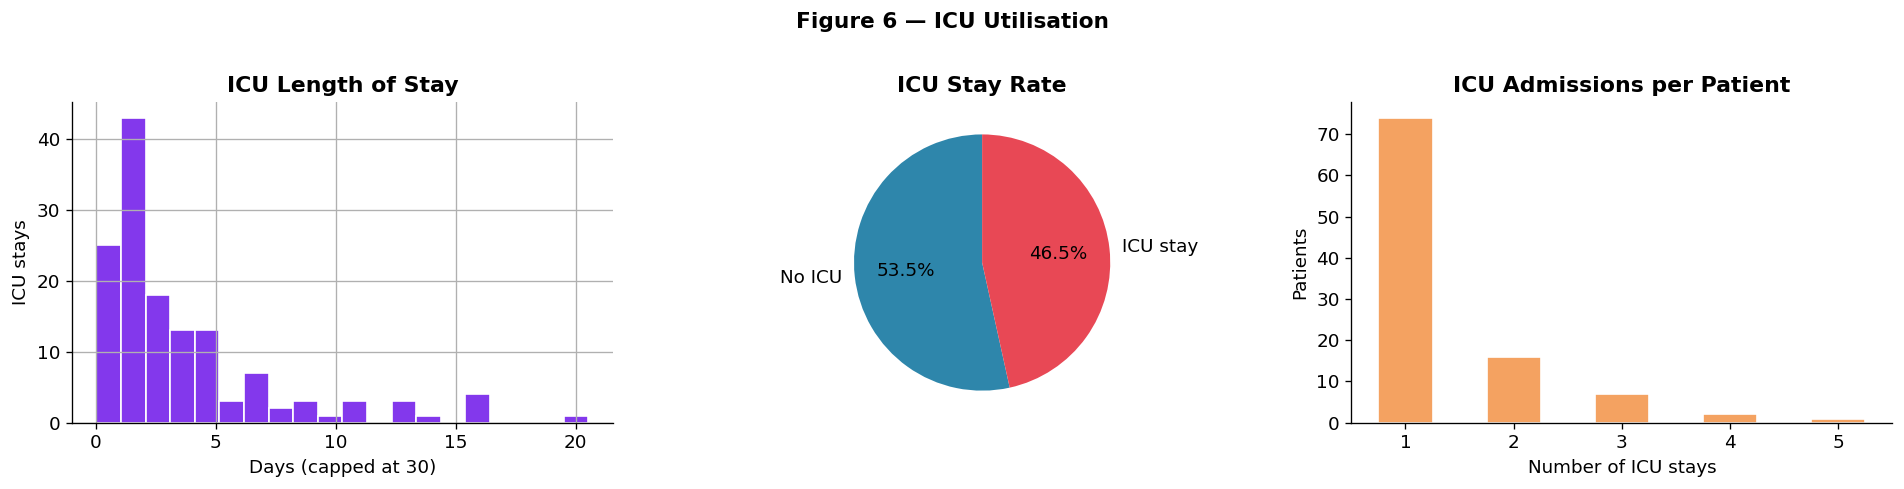

Admissions with ICU stay : 128 (46.5%)
ICU LOS median : 2.2 days


In [8]:
# Identify admissions that involved an ICU stay
icu_hadm   = set(icustays['hadm_id'].unique())

admissions['had_icu'] = (
    admissions['hadm_id']
    .isin(icu_hadm)
    .astype(int)
)

# ICU stays per patient
icu_per_pt = icustays.groupby('subject_id').size()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ICU Length of Stay distribution
icustays['los'].clip(0, 30).hist(
    bins=20,
    ax=axes[0],
    color=PALETTE[4],
    edgecolor='white'
)

axes[0].set_title('ICU Length of Stay', fontweight='bold')
axes[0].set_xlabel('Days (capped at 30)')
axes[0].set_ylabel('ICU stays')

# ICU admission proportion
icu_prop = admissions['had_icu'].value_counts()


axes[1].pie(
    icu_prop.values,
    labels=['No ICU', 'ICU stay'],
    colors=[PALETTE[0], PALETTE[1]],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)

axes[1].set_title('ICU Stay Rate', fontweight='bold')

# ICU admissions per patient
icu_per_pt.value_counts().sort_index().plot(
    kind='bar',
    ax=axes[2],
    color=PALETTE[2],
    edgecolor='white'
)

axes[2].set_title('ICU Admissions per Patient', fontweight='bold')
axes[2].set_xlabel('Number of ICU stays')
axes[2].set_ylabel('Patients')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle(
    'Figure 6 — ICU Utilisation',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()

plt.savefig(
    f'{PLOTS_DIR}/eda_06_icu_utilisation.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Summary Statistics
print(
    f'Admissions with ICU stay : {admissions["had_icu"].sum()} '
    f'({admissions["had_icu"].mean()*100:.1f}%)'
)

print(f'ICU LOS median : {icustays["los"].median():.1f} days')


## Temporal Patterns of Hospital Admissions

Temporal analysis of hospital admissions provides important context regarding dataset coverage and potential seasonal or longitudinal trends. Understanding when admissions occur can help identify patterns related to healthcare demand, epidemiological cycles, or institutional data collection periods.

This section examines admissions from two temporal perspectives:

1. **Admissions by Year** — Visualising annual admission counts allows assessment of dataset completeness across time and identification of any abrupt changes that may reflect shifts in data recording practices or healthcare utilisation.

2. **Admissions by Month** — Monthly admission patterns are analysed to explore potential seasonal variations in hospital activity, which may be influenced by environmental factors, infectious disease trends, or population health behaviours.

Together, these analyses help ensure that temporal biases are recognised prior to modelling and provide insight into the representativeness of the dataset across time.

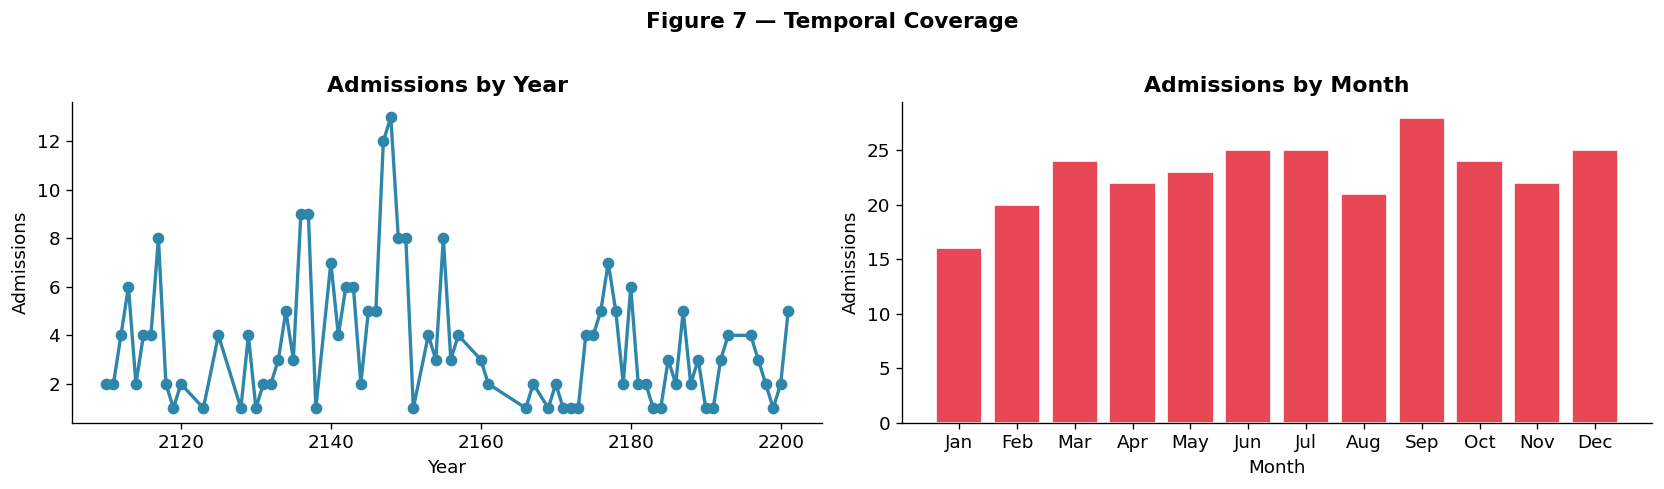

In [9]:
# Extract temporal features from admission timestamp
admissions['admit_year']  = admissions['admittime'].dt.year
admissions['admit_month'] = admissions['admittime'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Admissions by Year
yr = (
    admissions['admit_year']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

axes[0].plot(
    yr.index,
    yr.values,
    marker='o',
    linewidth=2,
    color=PALETTE[0]
)

axes[0].set_title('Admissions by Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Admissions')

# Admissions by Month
month_names = [
    'Jan','Feb','Mar','Apr','May','Jun',
    'Jul','Aug','Sep','Oct','Nov','Dec'
]

mo = admissions['admit_month'].value_counts().sort_index()

axes[1].bar(
    month_names,
    [mo.get(i, 0) for i in range(1, 13)],
    color=PALETTE[1],
    edgecolor='white'
)

axes[1].set_title('Admissions by Month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Admissions')

plt.suptitle('Figure 7 — Temporal Coverage', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/eda_07_temporal_coverage.png', dpi=150, bbox_inches='tight')
plt.show()


## Comorbidity Co-occurrence Analysis

Patients often present with multiple concurrent medical conditions, and understanding patterns of diagnostic co-occurrence provides valuable insight into disease relationships and patient complexity. Analysing comorbidity structures can help identify clinically meaningful clusters of conditions and inform feature engineering strategies for predictive modelling.

In this section, the most frequent diagnoses are first identified, and a binary presence matrix is constructed at the admission level to indicate whether each diagnosis occurs within a given hospital encounter. Pairwise co-occurrence counts are then computed to quantify how often diagnoses appear together.

The resulting heatmap visualises comorbidity relationships among the most common conditions, highlighting potential associations between disease categories. Such patterns may reflect shared risk factors, causal pathways, or common complications observed in clinical practice.

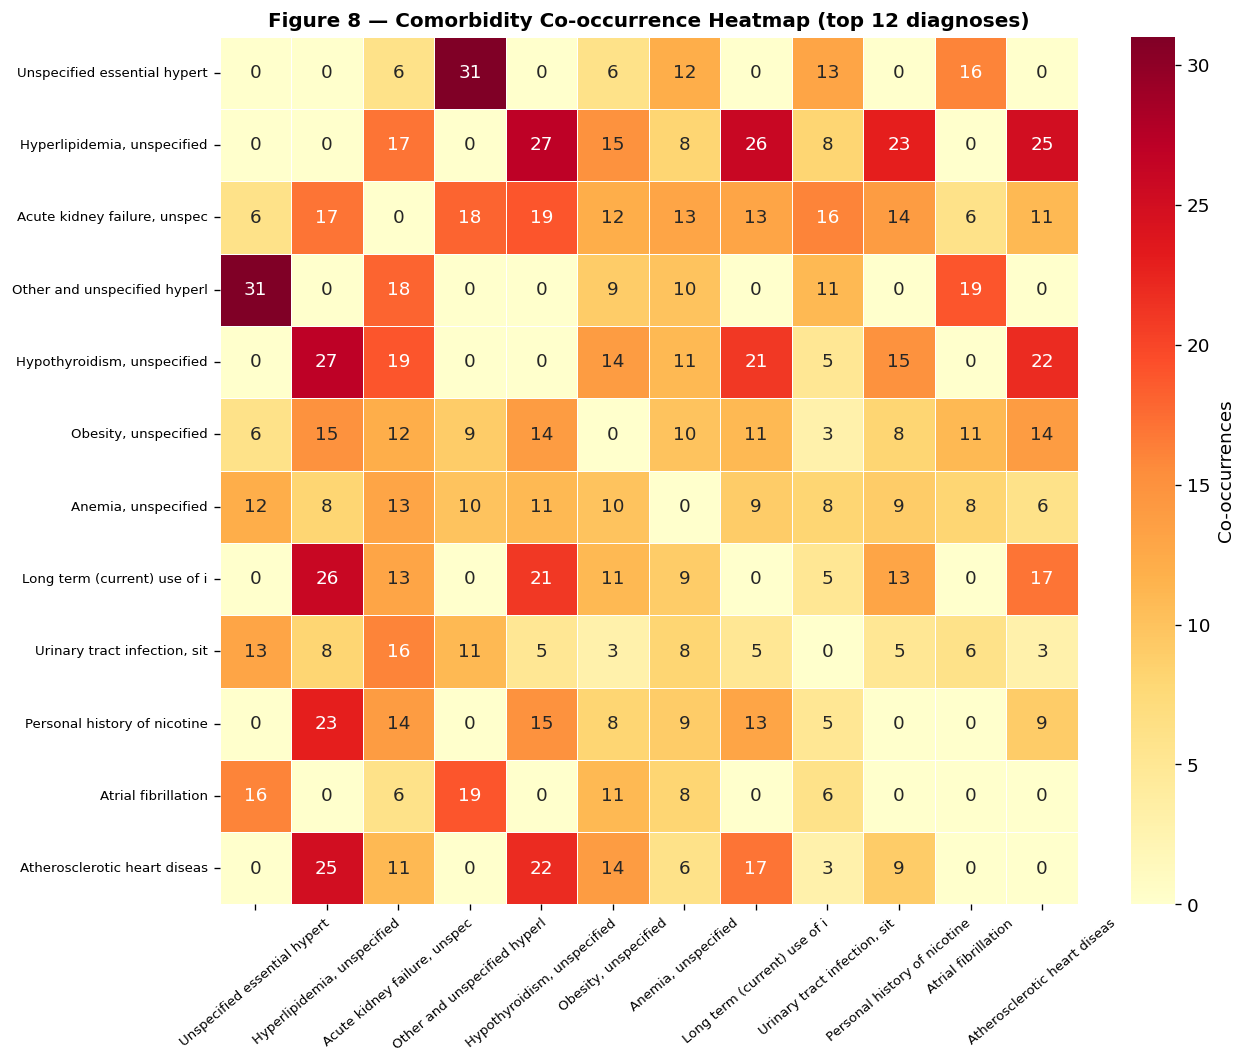

In [10]:
# Identify top 12 most frequent diagnoses
top12_titles = diagnoses_named['long_title'].value_counts().head(12).index.tolist()
top12_short  = [t[:28] for t in top12_titles]

# Create set of valid admission IDs
hadm_set     = set(admissions['hadm_id'].tolist())

# Construct binary presence matrix
presence = pd.DataFrame(
    0,
    index=list(hadm_set),
    columns=top12_short
)

for title, short in zip(top12_titles, top12_short):
    # Admissions containing the diagnosis
    ids = diagnoses_named[
        diagnoses_named['long_title'] == title
    ]['hadm_id'].unique()

    # Keep only admissions present in admissions table
    valid = [h for h in ids if h in hadm_set]

    presence.loc[valid, short] = 1

# Compute co-occurrence matrix
cooccur = presence.T.dot(presence)

# Set diagonal to zero safely
for i in range(len(cooccur)):
    cooccur.iat[i, i] = 0

# Visualise comorbidity heatmap
fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    cooccur,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Co-occurrences'}
)

ax.set_title(
    'Figure 8 — Comorbidity Co-occurrence Heatmap (top 12 diagnoses)',
    fontsize=12,
    fontweight='bold'
)

ax.tick_params(axis='x', rotation=40, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)


# Save figure
plt.tight_layout()

plt.savefig(
    f'{PLOTS_DIR}/eda_08_comorbidity_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Exploratory Data Analysis Summary

This section presents a consolidated summary of key descriptive statistics derived from the exploratory analysis. The objective is to provide a concise quantitative overview of dataset scale, patient characteristics, and healthcare utilisation metrics that will be referenced in subsequent modelling stages and report sections.

The summary includes cohort size, admission volume, diagnostic diversity, laboratory data coverage, ICU utilisation, and prescription records. Additionally, central demographic and utilisation indicators such as average patient age, admission frequency, median length of stay, and ICU admission proportion are reported.

These statistics serve as a validation checkpoint confirming dataset integrity and completeness, while also establishing contextual baseline information for the predictive modelling framework described in later notebooks.

In [11]:
# Print consolidated EDA summary statistics
print('═' * 55)
print('  EDA SUMMARY ')
print('═' * 55)

# Cohort size
print(f'  Unique patients : {patients.shape[0]}')

# Admission and diagnosis scale
print(f'  Total admissions : {admissions.shape[0]:,}')
print(f'  Total diagnoses (ICD) : {diagnoses.shape[0]:,}')
print(f'  Unique ICD codes : {diagnoses["icd_code"].nunique()}')

# Laboratory and ICU coverage
print(f'  Total lab events : {labevents.shape[0]:,}')
print(f'  Total ICU stays : {icustays.shape[0]:,}')

# Medication records
print(f'  Total prescriptions : {prescriptions.shape[0]:,}')

# Demographics
print(
      f'  Age  mean ± std : {patients["anchor_age"].mean():.1f} '
      f'± {patients["anchor_age"].std():.1f}'
)

# Healthcare utilisation metrics
print(f'  Avg admissions / patient : {adm_per_pt.mean():.2f}')
print(f'  LOS  median (days) : {los_clean.median():.1f}')

# ICU utilisation proportion
print(
      f'  Admissions with ICU stay : '
      f'{admissions["had_icu"].mean()*100:.1f}%'
)

print('═' * 55)

═══════════════════════════════════════════════════════
  EDA SUMMARY 
═══════════════════════════════════════════════════════
  Unique patients : 100
  Total admissions : 275
  Total diagnoses (ICD) : 4,506
  Unique ICD codes : 1472
  Total lab events : 107,727
  Total ICU stays : 140
  Total prescriptions : 18,087
  Age  mean ± std : 61.8 ± 16.2
  Avg admissions / patient : 2.75
  LOS  median (days) : 4.9
  Admissions with ICU stay : 46.5%
═══════════════════════════════════════════════════════
